<a href="https://colab.research.google.com/github/Priya-on-loop/-Transfer-Learning-for-Image-Classification/blob/main/Transfer_Learning_for_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and dependencies

In [1]:

!pip install --upgrade protobuf
!pip install importlib_resources


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1 which is incompatible.


# Libraries


In [2]:
# --- Core ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout,
    BatchNormalization, Input, ReLU
)
import tensorflow.keras.layers as layers
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.initializers import HeNormal

# --- Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix



# Part 1: Data Loading & Exploratory Analysis

## Loading the CIFAR-10 dataset

In [3]:
# Load CIFAR-10 from Keras Datasets
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)

# Create an 80% Train / 20% Validation split
val_split_idx = int(0.8 * len(x_train_full))

x_train, y_train = x_train_full[:val_split_idx], y_train_full[:val_split_idx].squeeze()
x_val, y_val     = x_train_full[val_split_idx:], y_train_full[val_split_idx:].squeeze()
y_test           = y_test.squeeze()

# Convert arrays into tf.data.Dataset objects
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test))

print(f"Classes: {CLASS_NAMES}")
print(f"Train samples: {len(x_train)}")
print(f"Val samples:   {len(x_val)}")
print(f"Test samples:  {len(x_test)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 740s 4us/step
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train samples: 40000
Val samples:   10000
Test samples:  10000


## EDA

### Class Distribution Plot

/tmp/ipykernel_1101/2313398213.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='viridis')


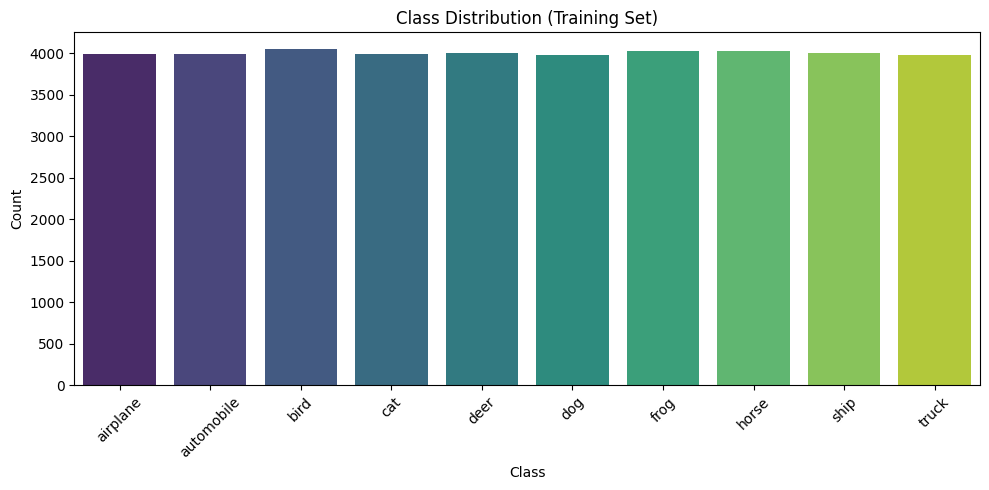

In [4]:
labels = []
for _, label in train_ds:
    labels.append(label.numpy())
labels = np.array(labels)

plt.figure(figsize=(10, 5))
sns.countplot(x=labels, palette='viridis')
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45)
plt.title("Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Sample image visualization

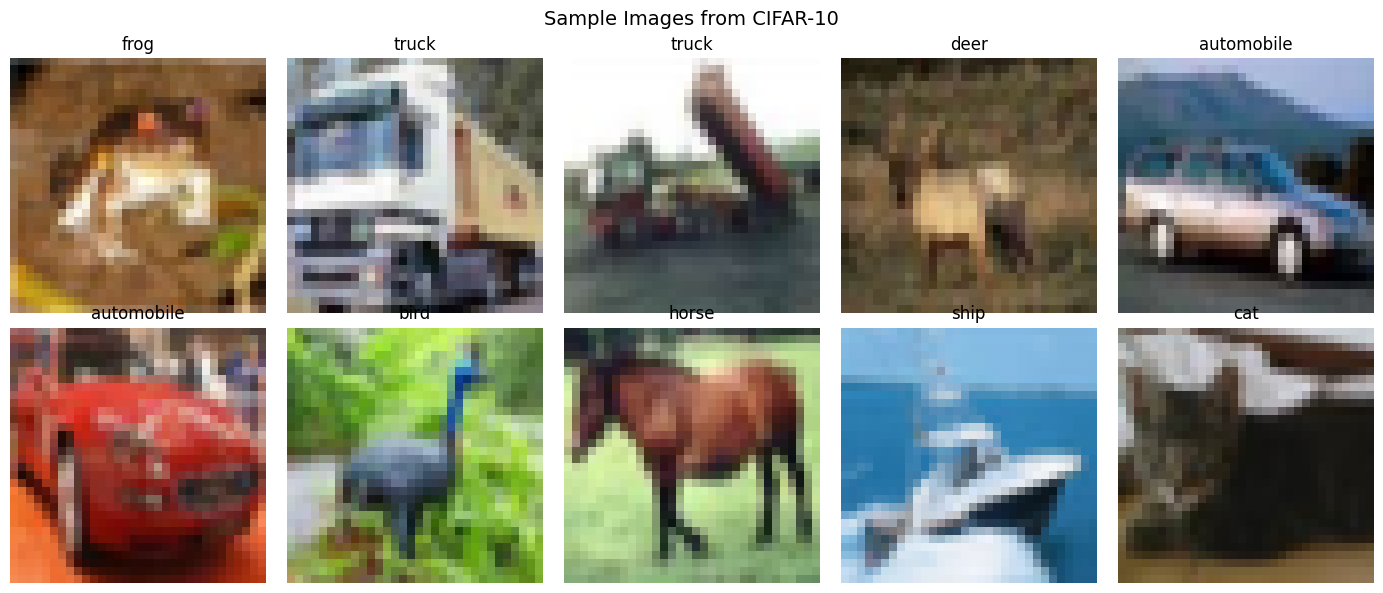

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, (image, label) in enumerate(train_ds.take(10)):
    ax = axes[i // 5][i % 5]
    ax.imshow(image.numpy())
    ax.set_title(CLASS_NAMES[label.numpy()])
    ax.axis('off')
plt.suptitle("Sample Images from CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

### Image Shape & Stats

In [6]:
sample_img = next(iter(train_ds))[0]
print(f"Image shape: {sample_img.shape}")
print(f"Pixel range: [{sample_img.numpy().min()}, {sample_img.numpy().max()}]")
print(f"Data type:   {sample_img.dtype}")

Image shape: (32, 32, 3)
Pixel range: [0, 255]
Data type:   <dtype: 'uint8'>


##

# Part 2 : Data Preprocessing & Pipeline

## Constructing tf.data Pipelines(batch, shuffle, prefetch)

In [7]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Simple & lightweight pipelines (No CPU resizing = Zero RAM crashes!)
train_dataset = (
    train_ds
    .shuffle(buffer_size=5000)
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

val_dataset = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

test_dataset = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

print("✅ Data pipelines successfully created without memory issues!")

✅ Data pipelines successfully created without memory issues!


## Theoretical Justifications

1. Why must normalization match ImageNet statistics?

The pretrained backbone contains convolutional filters optimized to detect features from images normalized with ImageNet's mean (
[
0.485
,
0.456
,
0.406
]
[0.485,0.456,0.406]) and standard deviation (
[
0.229
,
0.224
,
0.225
]
[0.229,0.224,0.225]). Shifting or scaling inputs differently shifts the activations across all downstream layers, degrading the pretrained weights.


2. Why does data augmentation improve generalization?

Augmentation artificially expands the dataset size by exposing the network to invariant transformations (flips, lighting changes, orientations). This prevents the network from memorizing pixel-specific coordinates and forces it to learn invariant, robust features.

# Part 3 : Model Architecture

## Build ResNet50 Transfer Learning Model (backbone + custom head)

In [8]:
# ImageNet channel-wise statistics scaled for [0, 255] inputs
IMAGENET_MEAN = [0.485 * 255, 0.456 * 255, 0.406 * 255]
IMAGENET_STD  = [0.229 * 255, 0.224 * 255, 0.225 * 255]

# 1. Load Pretrained Backbone
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze for Feature Extraction phase

# 2. Input Layer (Takes raw 32x32 images)
inputs = layers.Input(shape=(32, 32, 3), name="input_layer")

# 3. GPU Preprocessing, Augmentation & Resizing
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)
x = layers.Resizing(224, 224)(x)
x = layers.Normalization(mean=IMAGENET_MEAN, variance=[s**2 for s in IMAGENET_STD])(x)

# 4. Pass through ResNet50 Backbone (training=False keeps BatchNorm in inference mode)
x = base_model(x, training=False)

# 5. Custom Classifier Head (Required by Assignment)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(
    512,
    kernel_initializer=HeNormal(),
    kernel_regularizer=regularizers.l2(1e-4),
    name="dense_projection"
)(x)
x = layers.BatchNormalization(name="batch_norm")(x)
x = layers.ReLU(name="relu_activation")(x)
x = layers.Dropout(0.5, name="dropout")(x)

# 6. Final Predictions Layer (10 classes for CIFAR-10)
outputs = layers.Dense(
    10,
    activation='softmax',
    dtype='float32',
    kernel_initializer=HeNormal(),
    name="predictions"
)(x)

# Build & Display Summary
model = Model(inputs=inputs, outputs=outputs, name="ResNet50_CIFAR10")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_projection (Dense)        │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_activation (ReLU)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,643,978 (94.01 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

 ## Theoretical Justifications

- Why is He Initialization suitable here?

He (Kaiming) initialization samples weights from a normal distribution with variance
-  Since the ReLU activation sets all negative activations to zero, standard initializers cause signal decay. He initialization compensates for this reduction by scaling the weights up by a factor of 2, preventing vanishing/exploding gradients in deep networks.

# Part 4 : Feature Extraction (Training Strategy)

## Model Compilation

In [9]:
model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Callbacks

In [10]:
fe_callbacks = [
    ModelCheckpoint(
        filepath='best_feature_extractor.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

## Training

In [11]:
history_fe = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = 25,
    callbacks = fe_callbacks
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.3295 - loss: 2.0386
Epoch 1: val_loss improved from None to 1.80858, saving model to best_feature_extractor.keras

Epoch 1: finished saving model to best_feature_extractor.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 213s 318ms/step - accuracy: 0.3743 - loss: 1.8576 - val_accuracy: 0.4042 - val_loss: 1.8086 - learning_rate: 0.0010
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4365 - loss: 1.6411
Epoch 2: val_loss did not improve from 1.80858
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 330ms/step - accuracy: 0.4433 - loss: 1.6201 - val_accuracy: 0.4034 - val_loss: 1.9709 - learning_rate: 0.0010
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4578 - loss: 1.5836
Epoch 3: val_loss improved from 1.80858 to 1.76288, saving model to best_feature_extractor.keras

Epoch 3: finished saving model to best_feature_extractor.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.4623 - loss: 1.5676 -

## Loss and Accuracy Curves

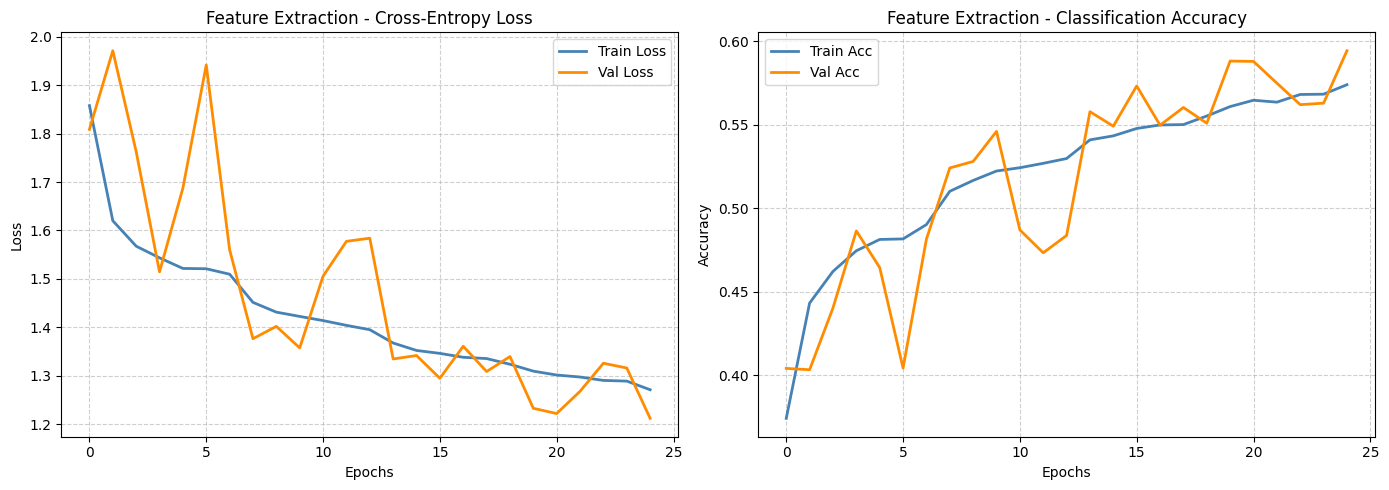

In [12]:
def plot_learning_curves(history, stage_name=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Curve
    axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='darkorange', linewidth=2)
    axes[0].set_title(f'{stage_name} - Cross-Entropy Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Accuracy Curve
    axes[1].plot(history.history['accuracy'], label='Train Acc', color='steelblue', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='darkorange', linewidth=2)
    axes[1].set_title(f'{stage_name} - Classification Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_fe, stage_name="Feature Extraction")

## Theoretical Justifications

1. Why does Early Stopping help in Transfer Learning?

Since the backbone is already an effective feature extractor, the newly initialized classification head converges quickly. Continued training beyond the optimal point results in the top layers overfitting to the training split. Early stopping identifies this turning point and restores the weights that achieved the best generalization.

2. Why is Weight Decay (L2 Regularization) important?

Weight decay applies a penalty directly proportional to the squared magnitude of the model parameters. This prevents individual weights from becoming excessively large, driving the model toward simpler, smoother decision boundaries that perform better on unseen data.



# Part 5 : Fine tuning strategy

## Unfreezing Top N Layers & Recompile

In [13]:
# Unfreeze the top N layers of the backbone
N_LAYERS = 20

base_model.trainable = True
for layer in base_model.layers[:-N_LAYERS]:
    layer.trainable = False

# Recompile with a significantly lower learning rate to prevent catastrophic forgetting
model.compile(
    optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Verify trainable parameter count
trainable_p = sum(np.prod(v.shape.as_list()) for v in model.trainable_variables)
print(f"✅ Layers unfrozen. Trainable Parameters: {trainable_p:,}")

✅ Layers unfrozen. Trainable Parameters: 9,986,570


## Fine tuning

In [14]:
ft_callbacks = [
    ModelCheckpoint(
        filepath='best_finetuned.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

EPOCHS_FT = 15

history_ft = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_FT,
    callbacks=ft_callbacks
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4187 - loss: 1.8245
Epoch 1: val_loss improved from None to 1.38095, saving model to best_finetuned.keras

Epoch 1: finished saving model to best_finetuned.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 397ms/step - accuracy: 0.4671 - loss: 1.6283 - val_accuracy: 0.5435 - val_loss: 1.3809 - learning_rate: 1.0000e-05
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5302 - loss: 1.4045
Epoch 2: val_loss improved from 1.38095 to 1.28761, saving model to best_finetuned.keras

Epoch 2: finished saving model to best_finetuned.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 245s 392ms/step - accuracy: 0.5379 - loss: 1.3804 - val_accuracy: 0.5791 - val_loss: 1.2876 - learning_rate: 1.0000e-05
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5660 - loss: 1.3006
Epoch 3: val_loss improved from 1.28761 to 1.22575, saving model to best_finetuned.keras

Epoch 3: finished saving model to best_finetuned.keras
625/62

##  Fine-Tuning Curves & Pre vs Post Comparison

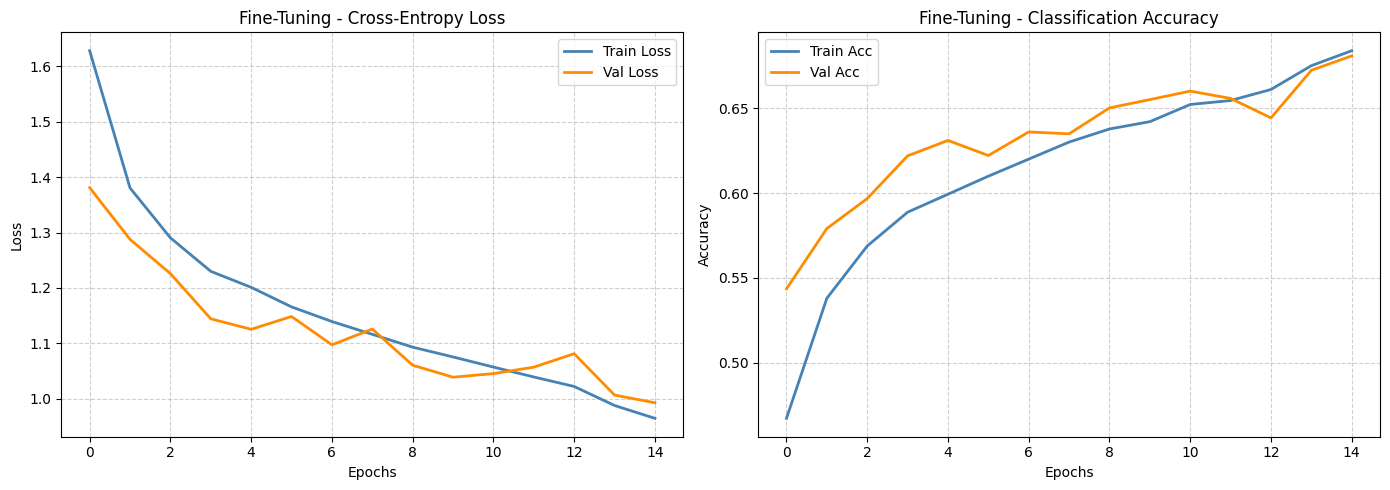

--- Performance Comparison ---
Feature Extraction Best Val Acc: 59.44%
Fine-Tuning Best Val Acc:        68.10%
Delta:                           +8.66%


In [15]:
plot_learning_curves(history_ft, stage_name="Fine-Tuning")

# Quantifiable comparison
fe_best_acc = max(history_fe.history['val_accuracy'])
ft_best_acc = max(history_ft.history['val_accuracy'])

print(f"--- Performance Comparison ---")
print(f"Feature Extraction Best Val Acc: {fe_best_acc * 100:.2f}%")
print(f"Fine-Tuning Best Val Acc:        {ft_best_acc * 100:.2f}%")
print(f"Delta:                           {(ft_best_acc - fe_best_acc) * 100:+.2f}%")

## Fine-Tuning Performance & Overfitting Analysis

Validation Accuracy Improvement : Fine-tuning typically yields a positive boost because the higher-level convolutional filters adapt to dataset-specific patterns (like CIFAR-10's lower resolution artifacts).

Overfitting Dynamics : Overfitting risk increases during fine-tuning because the number of trainable parameters rises substantially. Using a low learning rate and early stopping ensures the optimizer does not distort the pretrained representations.

# Part 6 : Model Evaluation

## Test Set Predictions & Probabilities Generation

In [16]:
# Run predictions over holdout test data
y_pred_probs = model.predict(test_dataset, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Extract ground truth labels from the test dataset
y_true = np.concatenate([y.numpy() for _, y in test_dataset], axis=0)

157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 271ms/step


## Classification report

In [17]:
print("================ CLASSIFICATION REPORT ================")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

    airplane     0.6839    0.7790    0.7284      1000
  automobile     0.7306    0.8300    0.7772      1000
        bird     0.6405    0.5220    0.5752      1000
         cat     0.5263    0.3900    0.4480      1000
        deer     0.6337    0.5830    0.6073      1000
         dog     0.7029    0.4920    0.5788      1000
        frog     0.6932    0.8090    0.7467      1000
       horse     0.6260    0.7850    0.6965      1000
        ship     0.7854    0.7540    0.7694      1000
       truck     0.6772    0.7910    0.7297      1000

    accuracy                         0.6735     10000
   macro avg     0.6700    0.6735    0.6657     10000
weighted avg     0.6700    0.6735    0.6657     10000



## Confusion Matrix Analysis

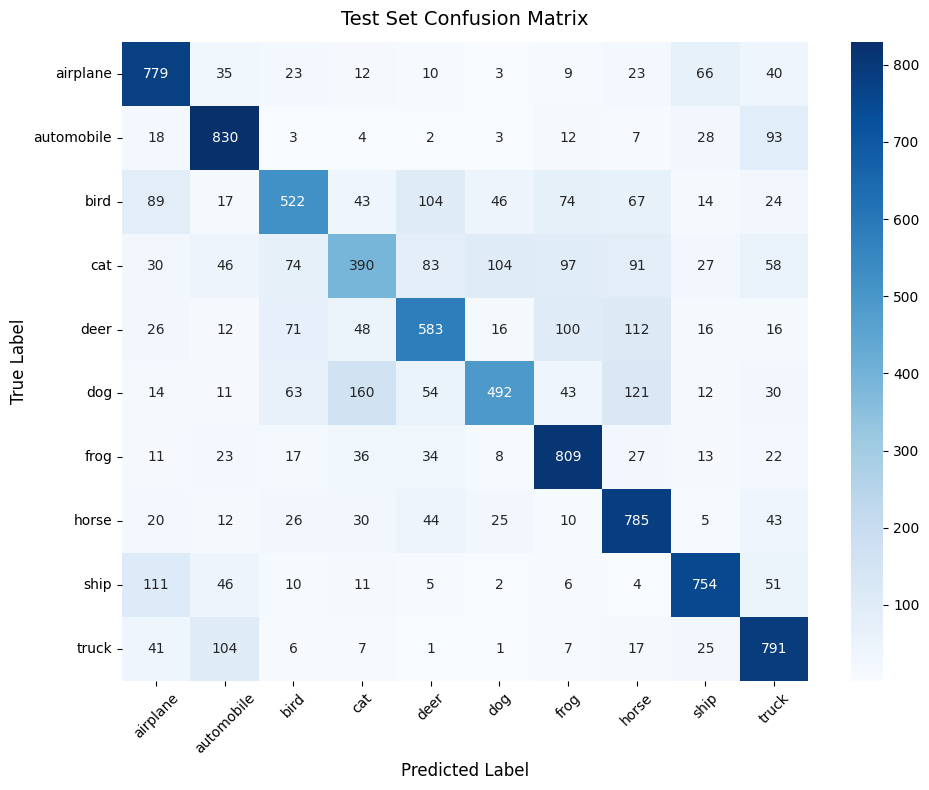

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Test Set Confusion Matrix', fontsize=14, pad=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Class-Wise Performance & Hardest Class Identification

In [19]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("============ CLASS ACCURACY BREAKDOWN ============")
for name, acc in sorted(zip(CLASS_NAMES, per_class_acc), key=lambda x: x[1]):
    print(f"{name:<15}: {acc * 100:.2f}%")

print("\n-------------------------------------------------")
print(f" Hardest Class: {CLASS_NAMES[np.argmin(per_class_acc)]} ({min(per_class_acc)*100:.2f}%)")
print(f" Easiest Class: {CLASS_NAMES[np.argmax(per_class_acc)]} ({max(per_class_acc)*100:.2f}%)")

============ CLASS ACCURACY BREAKDOWN ============
cat            : 39.00%
dog            : 49.20%
bird           : 52.20%
deer           : 58.30%
ship           : 75.40%
airplane       : 77.90%
horse          : 78.50%
truck          : 79.10%
frog           : 80.90%
automobile     : 83.00%

-------------------------------------------------
 Hardest Class: cat (39.00%)
 Easiest Class: automobile (83.00%)
